# 12 - Is the 0.78 Ceiling Features or Data? The School Questionnaire (Albania 2022)

Notebook 11 left one lever open. The multilevel model showed **~31% of risk variance is between schools** (null ICC), barely dented by student features - so the natural hypothesis was that the ~0.78 AUC ceiling is a *feature-set* limit and the missing signal lives in **school-level information** we simply had not linked in yet.

This notebook tests that hypothesis directly. We link the **PISA 2022 school questionnaire** (`CY08MSP_SCH_QQQ`, principal-reported: resources, staff shortage, class size, leadership, climate), joined onto students on `CNTSCHID`, and ask whether these *independent* school variables add predictive signal **beyond** the compositional `SCH_MEAN_*` features that already gave the 0.73→0.78 lift.

Crucially these are **exogenous school attributes** (a real, known property of a student's school at prediction time), not student aggregates - so unlike the composition features they carry no leave-one-out subtlety and need no fold-safe recomputation. The heavy fitting is in `scripts/run_school_questionnaire_experiment.py`; this notebook loads its result.

> **Distinction that matters.** `SCH_MEAN_ESCS` = *who attends* the school (composition, built from students). `SCHQ_EDUSHORT` = *what the school has* (inputs, reported by the principal). If the ceiling were a feature-set limit, the second should add signal the first cannot.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

## 1. What we linked

One row per school (274 Albanian schools, a 1:1 match to the sampled students), 13 principal-reported variables. Missingness is low except the computer ratio.

In [2]:
sch = pd.read_parquet('../data/processed/alb_2022_school.parquet')
print(f'{len(sch)} schools x {sch.shape[1]-1} questionnaire vars')
miss = (sch.drop(columns=['CNTSCHID']).isna().mean()*100).round(1).sort_values(ascending=False)
miss.to_frame('missing_%')

274 schools x 13 questionnaire vars


,missing_%
RATCMP1,13.9
PROATCE,7.3
STRATIO,4.4
SCHSIZE,4.4
TOTAT,1.8
CLSIZE,1.1
EDULEAD,1.1
INSTLEAD,1.1
STUBEHA,1.1
TEACHBEHA,1.1


## 2. The ablation - does the questionnaire add signal beyond composition?

Three nested feature sets on **one shared** 5×4 repeated-stratified-CV loop (per-fold AUCs perfectly paired), weighted metrics, Nadeau-Bengio corrected resampled *t*-test:

- **base** - 13 student features
- **+composition** - base + survey-weighted `SCH_MEAN_*` + cohort size (current headline)
- **+questionnaire** - +composition + `SCHQ_*` (the new lever)

The test that matters is the **incremental** one: questionnaire *over* composition.

In [3]:
ab = pd.read_csv('../outputs/results/school_questionnaire_ablation_2022.csv')
ab.round(4)

,model,auc_base,auc_composition,auc_questionnaire,delta_comp_vs_base,p_comp,delta_q_vs_comp,p_q,q_significant_5pct
0,catboost,0.7230,0.7797,0.7840,0.0567,0.0,0.0043,0.2488,False
1,gradient_boosting,0.7220,0.7768,0.7810,0.0548,0.0,0.0042,0.2469,False
2,lightgbm,0.7104,0.7716,0.7743,0.0612,0.0,0.0027,0.6622,False
3,random_forest,0.7038,0.7658,0.7672,0.0620,0.0,0.0014,0.6255,False
4,logistic_regression,0.7003,0.7342,0.7358,0.0339,0.0,0.0016,0.5606,False


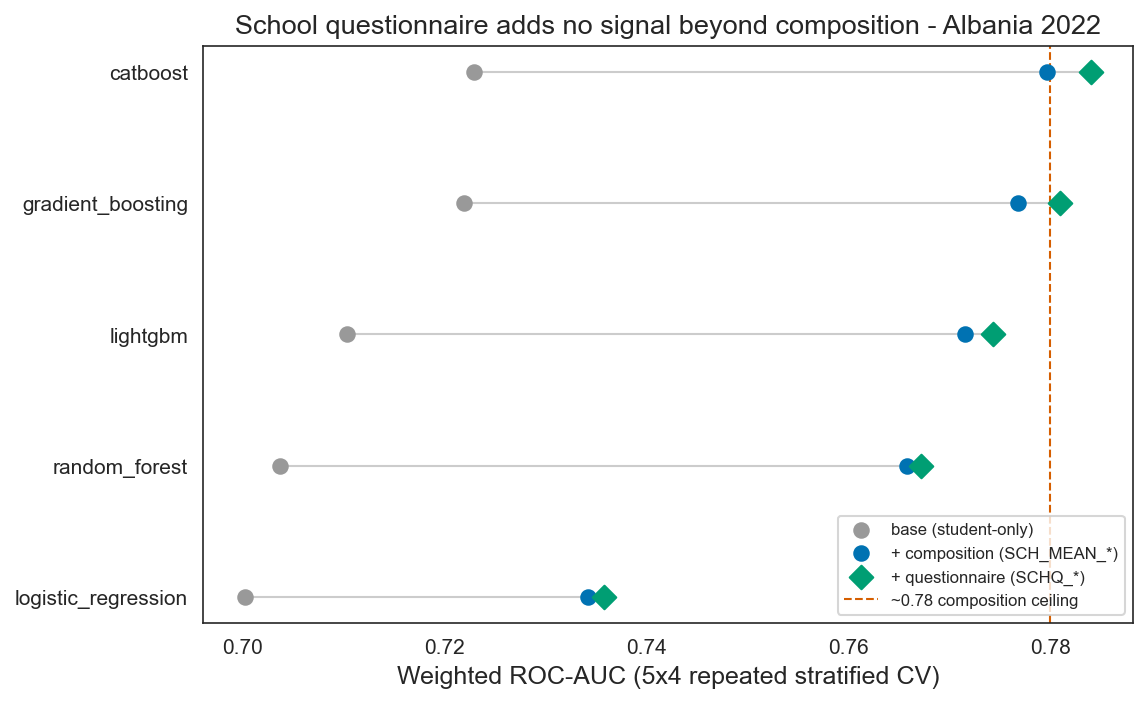

In [4]:
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
d = ab.sort_values('auc_questionnaire')
yp = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(d.auc_base, yp, color='0.6', s=48, label='base (student-only)', zorder=3)
ax.scatter(d.auc_composition, yp, color=PALETTE['blue'], s=48, label='+ composition (SCH_MEAN_*)', zorder=3)
ax.scatter(d.auc_questionnaire, yp, color=PALETTE['green'], s=64, marker='D', label='+ questionnaire (SCHQ_*)', zorder=3)
for i,(b,c,q) in enumerate(zip(d.auc_base,d.auc_composition,d.auc_questionnaire)):
    ax.plot([b,q],[i,i], color='0.8', lw=1, zorder=1)
ax.axvline(0.78, color=PALETTE['vermilion'], ls='--', lw=1, label='~0.78 composition ceiling')
ax.set_yticks(yp); ax.set_yticklabels(d.model)
ax.set_xlabel('Weighted ROC-AUC (5x4 repeated stratified CV)')
ax.set_title('School questionnaire adds no signal beyond composition - Albania 2022')
ax.legend(fontsize=8, loc='lower right'); plt.show()

**Reading:** the green diamonds (questionnaire) sit essentially on top of the blue dots (composition). The incremental lift is tiny - CatBoost **+0.004**, all models **< +0.005** - and **not significant for any model** (`p_q` all > 0.24). The big jump is base→composition (+0.05, highly significant); questionnaire→composition is noise.

## 3. Why composition already captures the school effect

The compositional features and the questionnaire inputs are correlated - a school's intake (`SCH_MEAN_ESCS`) tracks its resources and staffing - so once composition is in the model, the questionnaire is largely redundant. The between-school variance the multilevel ICC flagged is real, but for *prediction* it is already spanned by who attends the school; the measured inputs add little on top.

In [5]:
import numpy as np
stu = pd.read_parquet('../data/processed/alb_2022.parquet')
from src.features.engineer import add_school_aggregates, add_school_questionnaire
tmp = add_school_aggregates(stu, cols=['ESCS'])
tmp = add_school_questionnaire(tmp, sch, cols=['EDUSHORT','STAFFSHORT','STRATIO','PROATCE'])
cc = tmp[['SCH_MEAN_ESCS','SCHQ_EDUSHORT','SCHQ_STAFFSHORT','SCHQ_STRATIO','SCHQ_PROATCE']].corr()
cc['SCH_MEAN_ESCS'].round(3).to_frame('corr_with_SCH_MEAN_ESCS')

2026-07-04 10:11:11 [info     ] School aggregates added        cols=['ESCS'] n_schools=274


2026-07-04 10:11:11 [info     ] School questionnaire joined    cols=['SCHQ_EDUSHORT', 'SCHQ_STAFFSHORT', 'SCHQ_STRATIO', 'SCHQ_PROATCE'] n_schools=274 student_match_rate=1.0


,corr_with_SCH_MEAN_ESCS
SCH_MEAN_ESCS,1.000
SCHQ_EDUSHORT,-0.345
SCHQ_STAFFSHORT,-0.087
SCHQ_STRATIO,0.222
SCHQ_PROATCE,0.162


**Reading:** school-mean ESCS is materially correlated with the resource/staff measures - the composition feature is already a proxy for school inputs, which is why adding the raw inputs is redundant for prediction.

## Conclusions & Interpretation

- **The 0.78 ceiling is a genuine data limit, not a feature-set limit.** Linking the full PISA school questionnaire - the exact 'missing school-level information' notebook 11 pointed to - adds **no significant predictive signal** beyond the compositional school-mean features (best incremental +0.004 AUC, all *p* > 0.24). The deferred data-linkage lever is now **tested and closed**.
- **Composition subsumes inputs.** School-mean ESCS is correlated with staffing, resources and student-teacher ratio, so the compositional features already carry the school-level signal that matters for predicting individual low-proficiency risk.
- **This strengthens the headline story rather than weakening it.** Three independent routes - a school-mean booster, a random-intercept multilevel model (notebook 11), and now a direct school-questionnaire linkage - converge on the same ~0.78 ceiling. The limit is the information questionnaire data carries about a 15-year-old's math risk, not the model or an un-linked file.
- **Policy reading.** Since composition (who attends), not measured inputs (what the school has), is what predicts risk, interventions targeting *concentration of disadvantage* have more leverage here than uniform input top-ups - consistent with the compositional-effect literature.
- **Caveat.** This is a within-Albania predictive test; a school input can matter causally yet add no *marginal predictive* signal once composition is known. The questionnaire remains valuable for explanation and cross-country contrast (a natural extension), just not for lifting this AUC.